In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
import seaborn as sns


In [3]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])

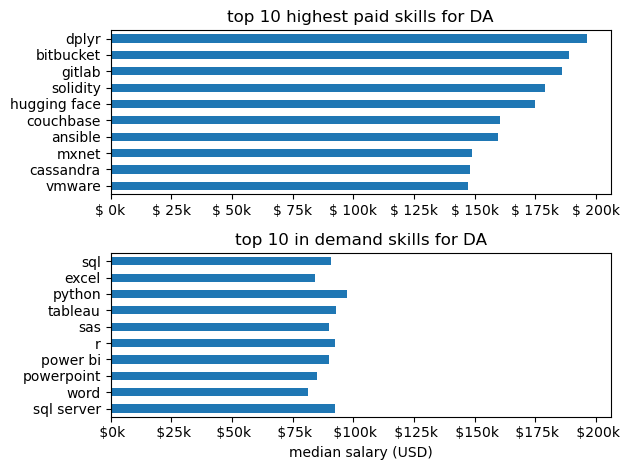

In [ ]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_top_pay = df_DA_top_pay.sort_values(by='median', ascending=False).head(10)

df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_skills = df_DA_skills.sort_values(by='count', ascending=False).head(10)

fig, ax = plt.subplots(2, 1)
#top 10 highest paid skills for DA
df_DA_top_pay[::-1].plot(kind='barh', y='median', ax = ax[0], legend=False)
ax[0].set_title('top 10 highest paid skills for DA')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'$ {int(x/1000)}k'))

#top 10 in demand skills for DA
df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('top 10 in demand skills for DA')
ax[1].set_ylabel('')
ax[1].set_xlabel('median salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f' ${int(x/1000)}k'))

plt.tight_layout()
plt.show()

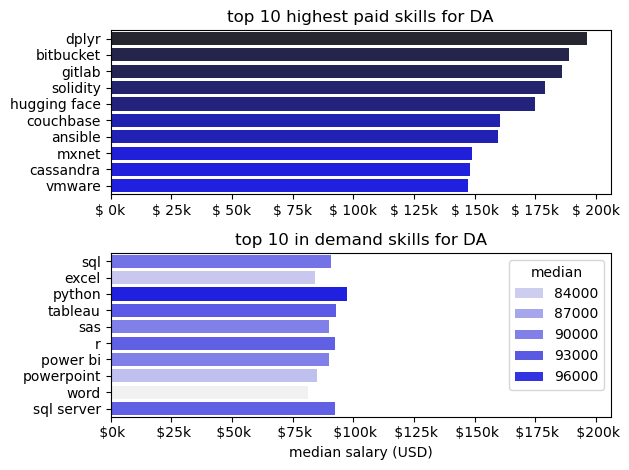

In [19]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_top_pay = df_DA_top_pay.sort_values(by='median', ascending=False).head(10)

df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_skills = df_DA_skills.sort_values(by='count', ascending=False).head(10)

fig, ax = plt.subplots(2, 1)
#top 10 highest paid skills for DA

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')  #r to reverse colour

#remove legend
ax[0].legend().remove()

#df_DA_top_pay[::-1].plot(kind='barh', y='median', ax = ax[0], legend=False)
ax[0].set_title('top 10 highest paid skills for DA')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'$ {int(x/1000)}k'))

#top 10 in demand skills for DA


sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:b')
#df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('top 10 in demand skills for DA')
ax[1].set_ylabel('')
ax[1].set_xlabel('median salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f' ${int(x/1000)}k'))

plt.tight_layout()
plt.show()

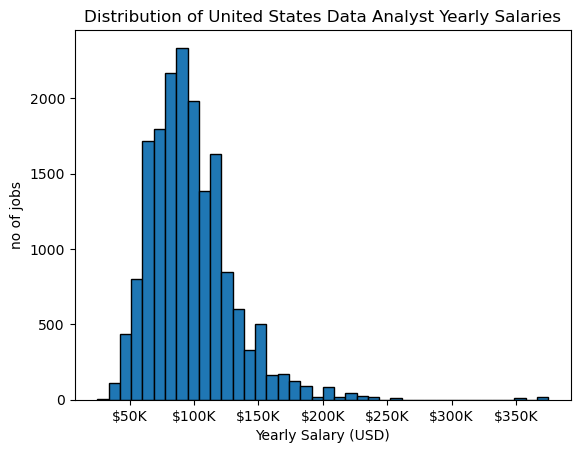

In [20]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('no of jobs') # Density is the probability of a random variable taking on a particular value
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

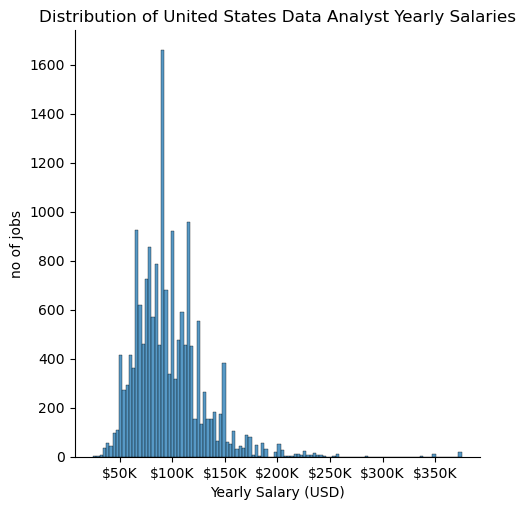

In [22]:
#df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')
sns.displot(df_DA_US['salary_year_avg'])

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('no of jobs') # Density is the probability of a random variable taking on a particular value
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

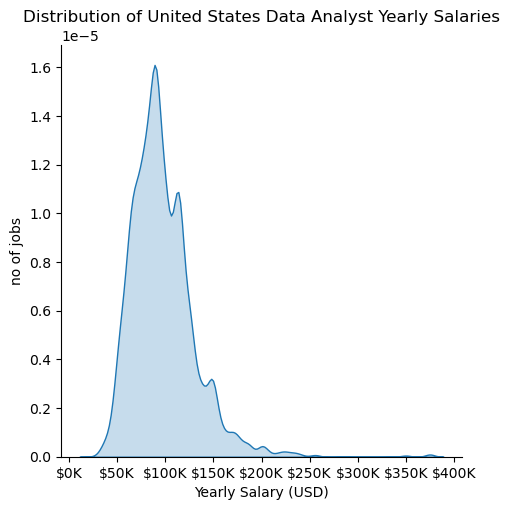

In [24]:
sns.displot(df_DA_US['salary_year_avg'], kind='kde', fill=True)

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('no of jobs') # Density is the probability of a random variable taking on a particular value
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()